In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Sample_arvyax_reflective_dataset.xlsx - Dataset_120.csv")
df.head()

,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,emotional_state,intensity
0,1,The ocean ambience helped me stop drifting and...,ocean,12,6.5,4,2,afternoon,mixed,calm_face,clear,focused,3
1,2,"I tried to relax during the forest ambience, y...",forest,35,6.0,2,4,evening,calm,tired_face,vague,restless,3
2,3,The forest session slowed my thoughts and I fe...,forest,3,NaN,2,1,night,overwhelmed,happy_face,clear,calm,3
3,4,"the mountain ambience was pleasant, though i c...",mountain,25,7.0,4,4,night,focused,calm_face,vague,neutral,1
4,5,"The rain session gave me a pause, but the pres...",rain,25,5.0,3,5,afternoon,NaN,tense_face,clear,overwhelmed,5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1200 non-null   int64  
 1   journal_text        1200 non-null   object 
 2   ambience_type       1200 non-null   object 
 3   duration_min        1200 non-null   int64  
 4   sleep_hours         1193 non-null   float64
 5   energy_level        1200 non-null   int64  
 6   stress_level        1200 non-null   int64  
 7   time_of_day         1200 non-null   object 
 8   previous_day_mood   1185 non-null   object 
 9   face_emotion_hint   1077 non-null   object 
 10  reflection_quality  1200 non-null   object 
 11  emotional_state     1200 non-null   object 
 12  intensity           1200 non-null   int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 122.0+ KB


In [4]:
df.isnull().sum()

,0
id,0
journal_text,0
ambience_type,0
duration_min,0
sleep_hours,7
energy_level,0
stress_level,0
time_of_day,0
previous_day_mood,15
face_emotion_hint,123


In [5]:
for col in ['sleep_hours', 'energy_level', 'stress_level']:
    df[col] = df[col].fillna(df[col].median())

In [6]:
for col in ['time_of_day', 'previous_day_mood', 'ambience_type','face_emotion_hint']:
    df[col] = df[col].fillna("unknown")

In [7]:
df['journal_text'] = df['journal_text'].fillna("")

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report

In [9]:
state_encoder = LabelEncoder()
df['state_encoded'] = state_encoder.fit_transform(df['emotional_state'])

In [10]:
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)
X_text = tfidf.fit_transform(df['journal_text'])

In [11]:
meta_cols = ['sleep_hours', 'energy_level', 'stress_level']
X_meta = df[meta_cols].values

In [12]:
scaler = StandardScaler()
X_meta_scaled = scaler.fit_transform(X_meta)

In [13]:
from xgboost import XGBClassifier
from scipy.sparse import hstack

In [14]:
X = hstack([X_text, X_meta_scaled])

In [15]:
cat_cols = ['time_of_day', 'previous_day_mood', 'ambience_type', 'face_emotion_hint']

X_cat = pd.get_dummies(df[cat_cols], drop_first=True)

X_meta_full = np.hstack([X_meta_scaled, X_cat.values])

In [16]:
from scipy.sparse import csr_matrix

X = hstack([X_text, csr_matrix(X_meta_full)])

In [17]:
y_state = df['state_encoded']
y_intensity = df['intensity']

In [18]:
X_train, X_test, y_state_train, y_state_test, train_idx, test_idx = train_test_split(
    X, y_state, df.index, test_size=0.2, random_state=42,stratify=y_state
)

X_int_train,X_int_test, y_int_train, y_int_test, train_int_idx, test_int_idx = train_test_split(
    X, y_intensity, df.index, test_size=0.2, random_state=42
)

test_df = df.loc[test_idx].reset_index(drop=True)

In [19]:
state_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.3,
    reg_lambda=1.5,
    eval_metric='mlogloss'
)
state_model.fit(X_train, y_state_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [20]:
intensity_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.3,
    reg_lambda=1.5,
    eval_metric='mlogloss'
)
intensity_model.fit(X_int_train, y_int_train - 1)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [21]:
state_probs = state_model.predict_proba(X_test)
state_preds = np.argmax(state_probs, axis=1)

intensity_preds = intensity_model.predict(X_test)

state_labels = state_encoder.inverse_transform(state_preds)

In [22]:
confidence = np.max(state_probs, axis=1)

entropy = -np.sum(state_probs * np.log(state_probs + 1e-9), axis=1)

reflection_quality_flag = (test_df['reflection_quality'] == "low").astype(int)

uncertain_flag = (
    (confidence < 0.6) |
    (entropy > 1.2) |
    (reflection_quality_flag == 1)
).astype(int)

In [23]:
def decide_action(state, intensity, stress, energy, time_of_day):

    # Normalize inputs
    stress = stress / 10 if stress > 1 else stress
    energy = energy / 10 if energy > 1 else energy
    intensity_score = intensity / 5.0

    high_stress = stress > 0.7
    low_energy = energy < 0.3
    high_energy = energy > 0.7
    high_intensity = intensity_score > 0.7


    if high_stress and low_energy:
        return "grounding", "now"

    if high_stress and high_energy:
        return "movement", "now"

    if state in ["overwhelmed", "anxious"] and high_intensity:
        return "box_breathing", "now"


    if low_energy:
        if time_of_day in ["night", "late_night"]:
            return "sleep", "tonight"
        else:
            return "rest", "within_15_min"

    if high_energy:
        if state in ["calm", "focused", "motivated"]:
            return "deep_work", "now"
        elif state in ["happy"]:
            return "deep_work", "within_15_min"
        else:
            return "movement", "within_15_min"

    if state in ["sad", "low", "reflective"]:
        if intensity_score > 0.5:
            return "journaling", "later_today"
        else:
            return "light_planning", "later_today"

    if state in ["anxious"]:
        return "breathing", "now"

    if state in ["confused", "uncertain"]:
        return "light_planning", "within_15_min"


    if time_of_day == "morning":
        if energy > 0.5:
            return "deep_work", "now"
        else:
            return "light_planning", "within_15_min"

    if time_of_day == "evening":
        if stress > 0.5:
            return "relaxation", "now"
        else:
            return "light_planning", "later_today"


    return "pause", "later_today"

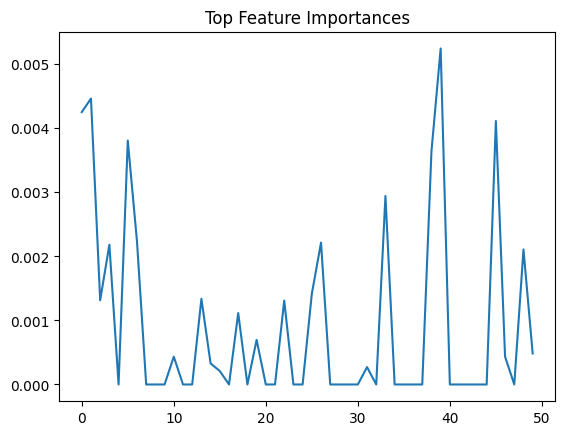

In [24]:
import matplotlib.pyplot as plt

importances = state_model.feature_importances_

plt.figure()
plt.plot(importances[:50])
plt.title("Top Feature Importances")
plt.show()

In [25]:
def generate_message(state, action):

    if state == "anxious":
        return "You seem a bit overwhelmed. Let’s slow things down with a short breathing exercise."

    if state in ["sad", "low"]:
        return "It looks like you're feeling low. Writing your thoughts might help you process things."

    if action == "deep_work":
        return "You're in a good state to focus. Let’s channel this into deep work."

    if action == "rest":
        return "Your energy seems low. A short rest could help reset you."

    return "Let’s take a small step to improve how you feel."


In [26]:
actions = []
timings = []

for i in range(len(test_df)):

    state = state_labels[i]
    intensity = intensity_preds[i]

    stress = test_df.loc[i, 'stress_level']
    energy = test_df.loc[i, 'energy_level']
    time_of_day = test_df.loc[i, 'time_of_day']

    action, when = decide_action(state, intensity, stress, energy, time_of_day)

    actions.append(action)
    timings.append(when)

In [27]:
messages = [generate_message(state_labels[i], actions[i]) for i in range(len(actions))]

In [28]:
output = pd.DataFrame({
    "id": test_df["id"],
    "predicted_state": state_labels,
    "predicted_intensity": intensity_preds,
    "confidence": confidence,
    "uncertain_flag": uncertain_flag,
    "what_to_do": actions,
    "when_to_do": timings,
    "message": messages
})

output.to_csv("predictions.csv", index=False)

In [29]:
print(classification_report(y_state_test, state_preds))

              precision    recall  f1-score   support

           0       0.66      0.67      0.67        43
           1       0.60      0.67      0.63        39
           2       0.71      0.58      0.64        38
           3       0.81      0.65      0.72        40
           4       0.76      0.76      0.76        38
           5       0.58      0.71      0.64        42

    accuracy                           0.68       240
   macro avg       0.69      0.67      0.68       240
weighted avg       0.69      0.68      0.68       240



In [30]:
X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y_state, test_size=0.2, random_state=42
)

model_text = XGBClassifier()
model_text.fit(X_text_train, y_train)

print("Text-only Accuracy:", model_text.score(X_text_test, y_test))

Text-only Accuracy: 0.6791666666666667


In [31]:
X_meta_train, X_meta_test, y_train, y_test = train_test_split(
    X_meta_scaled, y_state, test_size=0.2, random_state=42
)

model_meta = XGBClassifier()
model_meta.fit(X_meta_train, y_train)

print("Metadata-only Accuracy:", model_meta.score(X_meta_test, y_test))

Metadata-only Accuracy: 0.16666666666666666


In [32]:
print("Combined Accuracy:", state_model.score(X_test, y_state_test))

Combined Accuracy: 0.675


In [35]:
def preprocess(df):

    df = df.copy()

    # Fill numeric
    for col in ['sleep_hours', 'energy_level', 'stress_level']:
        df[col] = df[col].fillna(df[col].median())

    # Fill categorical
    for col in ['time_of_day', 'previous_day_mood']:
        df[col] = df[col].fillna("unknown")

    # Fill text
    df['journal_text'] = df['journal_text'].fillna("")

    return df

In [36]:
from scipy.sparse import csr_matrix, hstack

def build_features(df, tfidf, scaler, fit=True):

    # TEXT FEATURES
    if fit:
        X_text = tfidf.fit_transform(df['journal_text'])
    else:
        X_text = tfidf.transform(df['journal_text'])

    # NUMERIC FEATURES
    X_meta = df[['sleep_hours', 'energy_level', 'stress_level']].values

    if fit:
        X_meta_scaled = scaler.fit_transform(X_meta)
    else:
        X_meta_scaled = scaler.transform(X_meta)

    # Give more importance to metadata
    X_meta_scaled = X_meta_scaled * 3

    # Combine
    X = hstack([X_text, csr_matrix(X_meta_scaled)])

    return X

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier

# Encoders
state_encoder = LabelEncoder()

# Feature tools
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
scaler = StandardScaler()

In [45]:
def train_pipeline(df):

    df = preprocess(df)

    # Encode target
    df['state_encoded'] = state_encoder.fit_transform(df['emotional_state'])

    X = build_features(df, tfidf, scaler, fit=True)

    y_state = df['state_encoded']
    y_intensity = df['intensity'] - 1

    from sklearn.model_selection import train_test_split

    X_train, X_test, y_state_train, y_state_test, train_idx, test_idx = train_test_split(
        X, y_state, df.index, test_size=0.2, random_state=42, stratify=y_state
    )

    x_int_train, x_int_test, y_int_train, y_int_test, train_int_idx, test_int_idx = train_test_split(
        X, y_intensity, df.index, test_size=0.2, random_state=42
    )

    # MODELS
    state_model = XGBClassifier(
        n_estimators=250,
        max_depth=5,
        learning_rate=0.07,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss'
    )

    intensity_model = XGBClassifier(
        n_estimators=250,
        max_depth=5
    )

    # TRAIN
    state_model.fit(X_train, y_state_train)
    intensity_model.fit(x_int_train, y_int_train)

    # Save test df
    test_df = df.loc[test_idx].reset_index(drop=True)

    return {
        "state_model": state_model,
        "intensity_model": intensity_model,
        "X_test": X_test,
        "y_state_test": y_state_test,
        "test_df": test_df
    }

In [46]:
import numpy as np

def predict_pipeline(df_input, state_model, intensity_model):

    df_input = preprocess(df_input)

    X_input = build_features(df_input, tfidf, scaler, fit=False)

    # STATE
    state_probs = state_model.predict_proba(X_input)
    state_preds = np.argmax(state_probs, axis=1)
    state_labels = state_encoder.inverse_transform(state_preds)

    # INTENSITY
    intensity_preds = intensity_model.predict(X_input)

    return state_labels, intensity_preds, state_probs

In [47]:
def compute_uncertainty(state_probs, df_input):

    confidence = np.max(state_probs, axis=1)

    entropy = -np.sum(state_probs * np.log(state_probs + 1e-9), axis=1)

    reflection_flag = (df_input['reflection_quality'] == "low").astype(int)

    uncertain_flag = (
        (confidence < 0.6) |
        (entropy > 1.2) |
        (reflection_flag == 1)
    ).astype(int)

    return confidence, uncertain_flag

In [48]:
def decide_action(state, intensity, stress, energy, time_of_day, uncertain=0):

    # Normalize inputs
    stress = stress / 10 if stress > 1 else stress
    energy = energy / 10 if energy > 1 else energy
    intensity_score = intensity / 5.0

    # -----------------------------
    # 0. UNCERTAINTY HANDLING (VERY IMPORTANT)
    # -----------------------------
    if uncertain == 1:
        # Safe fallback actions
        if energy < 0.4:
            return "pause", "within_15_min"
        else:
            return "light_planning", "later_today"

    # -----------------------------
    # 1. CRITICAL STATES (Immediate)
    # -----------------------------
    if stress > 0.75 and energy < 0.5:
        return "grounding", "now"

    if stress > 0.75 and energy > 0.5:
        return "movement", "now"

    if state in ["overwhelmed", "anxious"] and intensity_score > 0.7:
        return "box_breathing", "now"

    # -----------------------------
    # 2. ENERGY BASED DECISIONS
    # -----------------------------
    if energy < 0.3:
        if time_of_day in ["night", "late_night"]:
            return "sleep", "tonight"
        else:
            return "rest", "within_15_min"

    if energy > 0.7:
        if state in ["calm", "focused", "motivated"]:
            return "deep_work", "now"
        elif state == "happy":
            return "deep_work", "within_15_min"
        else:
            return "movement", "within_15_min"

    # -----------------------------
    # 3. EMOTION BASED DECISIONS
    # -----------------------------
    if state in ["sad", "low", "reflective"]:
        if intensity_score > 0.6:
            return "journaling", "later_today"
        else:
            return "light_planning", "later_today"

    if state == "anxious":
        return "breathing", "now"

    if state in ["confused", "uncertain"]:
        return "light_planning", "within_15_min"

    # -----------------------------
    # 4. TIME-AWARE ADJUSTMENTS
    # -----------------------------
    if time_of_day == "morning":
        if energy > 0.5:
            return "deep_work", "now"
        else:
            return "light_planning", "within_15_min"

    if time_of_day == "evening":
        if stress > 0.5:
            return "relaxation", "now"
        else:
            return "light_planning", "later_today"

    if time_of_day in ["night", "late_night"]:
        if energy < 0.4:
            return "sleep", "tonight"
        else:
            return "journaling", "tonight"

    # -----------------------------
    # 5. DEFAULT FALLBACK
    # -----------------------------
    return "pause", "later_today"

In [49]:
actions = []
timings = []

for i in range(len(test_df)):

    action, when = decide_action(
        state_labels[i],
        intensity_preds[i],
        test_df.loc[i, 'stress_level'],
        test_df.loc[i, 'energy_level'],
        test_df.loc[i, 'time_of_day'],
        uncertain_flag[i]   # 🔥 NEW
    )

    actions.append(action)
    timings.append(when)

In [50]:
# TRAIN
pipeline = train_pipeline(df)

state_model = pipeline["state_model"]
intensity_model = pipeline["intensity_model"]
X_test = pipeline["X_test"]
test_df = pipeline["test_df"]

# PREDICT
state_labels, intensity_preds, state_probs = predict_pipeline(
    test_df, state_model, intensity_model
)

# UNCERTAINTY
confidence, uncertain_flag = compute_uncertainty(state_probs, test_df)

# DECISION
actions = []
timings = []

for i in range(len(test_df)):
    action, when = decide_action(
        state_labels[i],
        intensity_preds[i],
        test_df.loc[i, 'stress_level'],
        test_df.loc[i, 'energy_level'],
        test_df.loc[i, 'time_of_day']
    )

    actions.append(action)
    timings.append(when)

In [55]:
def run_pipeline(pipeline):

    state_model = pipeline["state_model"]
    intensity_model = pipeline["intensity_model"]

    test_df = pipeline["test_df"]

    # Build features
    X_test = build_features(test_df, tfidf, scaler, fit=False)

    # Predictions
    state_probs = state_model.predict_proba(X_test)
    state_preds = np.argmax(state_probs, axis=1)
    state_labels = state_encoder.inverse_transform(state_preds)

    intensity_preds = intensity_model.predict(X_test) + 1

    # Uncertainty
    confidence = np.max(state_probs, axis=1)

    entropy = -np.sum(state_probs * np.log(state_probs + 1e-9), axis=1)

    reflection_flag = (test_df['reflection_quality'] == "low").astype(int)

    uncertain_flag = (
        (confidence < 0.6) |
        (entropy > 1.2) |
        (reflection_flag == 1)
    ).astype(int)

    # Decision
    actions = []
    timings = []

    for i in range(len(test_df)):
        action, when = decide_action(
            state_labels[i],
            intensity_preds[i],
            test_df.loc[i, 'stress_level'],
            test_df.loc[i, 'energy_level'],
            test_df.loc[i, 'time_of_day'],
            uncertain_flag[i]
        )

        actions.append(action)
        timings.append(when)

    # Output
    output = pd.DataFrame({
        "id": test_df["id"],
        "predicted_state": state_labels,
        "predicted_intensity": intensity_preds,
        "confidence": confidence,
        "uncertain_flag": uncertain_flag,
        "what_to_do": actions,
        "when_to_do": timings
    })

    return output

In [56]:
df = pd.read_csv("Sample_arvyax_reflective_dataset.xlsx - Dataset_120.csv")

pipeline = train_pipeline(df)

output = run_pipeline(pipeline)

output.to_csv("predictions.csv", index=False)

print("✅ DONE — predictions.csv generated")

✅ DONE — predictions.csv generated


In [57]:
df = pd.read_csv("Sample_arvyax_reflective_dataset.xlsx - Dataset_120.csv")

pipeline = train_pipeline(df)

output = run_pipeline(pipeline)

output.to_csv("predictions.csv", index=False)

print("✅ DONE — predictions.csv generated")

✅ DONE — predictions.csv generated
